In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ultranest
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.signal import savgol_filter
import matplotlib.gridspec as gridspec


In [2]:
%matplotlib widget

In [3]:
# Import and plot the raw spectra of the aspirin measurements
# There are two sets of spectra based on the focus conditions of the XPS instrument

data_path = Path(r'./averaged_data')
fig_path = Path(r'./figures')

legends_raw = ['Fuori fuoco', 'Focalizzato']
legends_smoothed_WA = ['Underfocused - Smoothed Counts (WA method)', 'Focused - Smoothed Counts (WA method)']
legends_smoothed_SG = ['Underfocused - Smoothed Counts (SG method)', 'Focused - Smoothed Counts (SG method)']

survey_files = [
    'aspirin_test_underfocused_Survey_2026-06-26__19h46m59s_alternative.txt',
    'aspirin_test_focused_Survey_2026-06-26__19h28m31s_alternative.txt',
]
c1s_files = [
    'aspirin_test_underfocused_C_1s_2026-06-26__20h15m53s_average.txt',
    'aspirin_test_focused_C_1s_2026-06-26__18h52m51s_average.txt',
]
o1s_files = [
    'aspirin_test_underfocused_O_1s_2026-06-26__19h56m37s_average.txt',
    'aspirin_test_focused_O_1s_2026-06-26__19h04m33s_average.txt',
]

all_files = [survey_files, c1s_files, o1s_files]
panel_labels = ['Survey', 'C 1s', 'O 1s']
photon_energy = 1486.6  # Al Kα
BE_shift = 2.8

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[kk] = {'Survey': dict, 'C1s': dict, 'O1s': dict}
for kk in range(len(legends_raw)):
    spectra.append({
        label: load_xps(data_path / flist[kk])
        for label, flist in zip(panel_labels, all_files)
    })

for entry in spectra:
    for label, d in entry.items():
        d['BE_eV'] = photon_energy - d['KE_eV']

In [ ]:
# Plot raw data — one figure per sample

pass_energies = [180, 30, 30] # survey, C 1s, O 1s
delta_E = [2, 0.2, 0.2]

for kk, legend in enumerate(legends_raw):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(legend, fontsize=14, fontweight='bold')

    for ax, label in zip(axes, panel_labels):
        s = spectra[kk][label]
        be  = s['BE_eV']
        y   = s['hits_counts']

        ax.plot(be, y, color='black', lw=0.5, marker='.', markersize=1)
        ax.set_xlim(be.max(), be.min())
        ax.set_xlabel('Energia di legame [eV]')
        ax.set_ylabel('Intensità [u.a.]')
        ax.set_title(label)
        ax.text(0.6, 0.95, 
                f'Pass energy: {pass_energies[panel_labels.index(label)]} eV \n' + r'$\Delta$E = ' + f'{delta_E[panel_labels.index(label)]} eV' + '\n' + r'Pressione: $3 \times 10^{-8}$ mbar',
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.8))

        # ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    fig.tight_layout()
    plt.savefig(fig_path / f'xps_{legend.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Plot focused survey spectrum with annotated peaks
Au_survey = spectra[1]['Survey']

data = [(288.0, 'C 1s'), (534.0, 'O 1s'), (979, 'O KLL'), (39, 'Mo 4p'), (60, 'Mo 4s'), (234, 'Mo 3d'), (398, 'Mo 3p'), (508, 'Mo 3s')]
BE_peaks, peaks_labels = zip(*data)
BE_peaks = list(BE_peaks)
peaks_labels = list(peaks_labels)

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(Au_survey['BE_eV'], Au_survey['hits_counts'], color='black', linewidth=0.7, marker='.', markersize=1)
ax.set_xlabel('Energia di legame [eV]', fontsize=12)
ax.set_ylabel('Intensità [u.a.]', fontsize=12)
ax.set_xlim(Au_survey['BE_eV'].max(), Au_survey['BE_eV'].min())
ax.set_ylim(Au_survey['hits_counts'].min(), Au_survey['hits_counts'].max()+2000)
ax.text(0.8, 0.95, 
                f'Pass energy: 180 eV \n' + r'$\Delta$E = 2 eV' + '\n' + r'Pressione: $3 \times 10^{-8}$ mbar',
                transform=ax.transAxes,
                fontsize=12,
                verticalalignment='top',
                horizontalalignment='left',
                bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.8))
for BE_peak, label in zip(BE_peaks, peaks_labels):
    idx = np.abs(Au_survey['BE_eV'] - BE_peak).argmin()
    peak_count = Au_survey['hits_counts'][idx]                  
    plt.annotate(
        label,
        (BE_peak, peak_count),
        textcoords="offset points",
        xytext=(0, 30),
        ha='center',
        va='center',
        rotation=90,          
        rotation_mode='anchor',
        fontsize=12, 
    )
fig.savefig(fig_path / f'{survey_files[1]}_presentazione.png', dpi=300, bbox_inches='tight')
plt.show()

In [83]:
# Helper functions for fitting

from scipy.special import wofz

def gaussian(x, pos, amp, fwhm):
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return amp * np.exp(-(x - pos)**2 / (2 * sigma**2))

def voigt(x, pos, amp, fwhm_G, fwhm_L):
    """
    Voigt profile = convolution of a Gaussian (fwhm_G) and Lorentzian (fwhm_L).
    Normalized so that the peak height at x=pos equals `amp`
    (consistent with the `gaussian()` convention above).
    """
    sigma = fwhm_G / (2 * np.sqrt(2 * np.log(2)))
    gamma = fwhm_L / 2.0

    # guard against degenerate sigma (pure Lorentzian limit)
    sigma = max(sigma, 1e-8)

    z  = ((x - pos) + 1j * gamma) / (sigma * np.sqrt(2))
    v  = wofz(z).real

    # peak value at x = pos, used to renormalize so max(v) == amp
    z0 = (1j * gamma) / (sigma * np.sqrt(2))
    v0 = wofz(z0).real

    return amp * v / v0

def multi_peak(x, *p, shape='gaussian'):
    """
    shape='gaussian': p = [pos1, amp1, fwhm1, pos2, amp2, fwhm2, ...]   (3 params/peak)
    shape='voigt':    p = [pos1, amp1, fwhmG1, fwhmL1, ...]             (4 params/peak)
    """
    npar = 3 if shape == 'gaussian' else 4
    n_peaks = len(p) // npar
    y = np.zeros_like(x, dtype=float)
    for k in range(n_peaks):
        seg = p[k*npar:(k+1)*npar]
        if shape == 'gaussian':
            y += gaussian(x, *seg)
        else:
            y += voigt(x, *seg)
    return y

# kept for backward compatibility (equivalent to multi_peak(..., shape='gaussian'))
def multi_gaussian(x, *p):
    return multi_peak(x, *p, shape='gaussian')

def shirley_background(x, y, max_iter=50, tol=1e-6):
    """Iterative Shirley background. x must be sorted ascending."""
    y1, y2 = y[0], y[-1]
    bg = np.linspace(y1, y2, len(y))  # linear initial guess

    for _ in range(max_iter):
        A_total = np.trapezoid(y - bg, x)
        if abs(A_total) < np.finfo(float).eps:
            A_total = np.finfo(float).eps
        A_cum = cumulative_trapezoid(y - bg, x, initial=0)
        new_bg = y1 + (y2 - y1) * A_cum / A_total
        if np.max(np.abs(new_bg - bg)) < tol:
            bg = new_bg
            break
        bg = new_bg
    return bg

def _plot_fit(r):
    fig = plt.figure(figsize=(9, 10))
    fig.suptitle(f"{r['label']} (" + r'$\chi^2_{red}$' + f"= {r['chi2_red']:.2f})", fontsize=13)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, :], sharex=ax_main)
    # ax_hist = fig.add_subplot(gs[2, :])

    be_full = r['be_full']
    y_full  = r['y_full']
    be      = r['be']       # fitting window only
    bg      = r['background']

    # full spectrum as scatter
    ax_main.plot(be_full, y_full, linewidth=1, c='k', marker='.', markersize=1, label='Dati', zorder=3)

    # fitted curves only within be_range
    ax_main.plot(be, bg, 'b--', lw=1.2, label='Fondo Shirley')
    ax_main.plot(be, r['fit_curve'] + bg, 'r-', lw=1.8, label='Fit completo')

    cmap = plt.cm.tab10
    for k, pk in enumerate(r['peak_params']):
        comp = r['components'][:, k] + bg
        ax_main.plot(be, comp, '-', color=cmap(k), lw=1.2,
                     label=f"{pk['label']} ({pk['position_eV']:.1f} eV, {100*pk['area_fraction']:.1f}%)")
        ax_main.fill_between(be, bg, comp, color=cmap(k), alpha=0.15)

    ax_main.set_xlim(be_full.max(), be_full.min())   # full range for x-axis
    ax_main.set_xlabel('Energia di legame [eV]', fontsize=12)
    ax_main.set_ylabel('Intensità [u.a.]', fontsize=12)
    ax_main.legend(fontsize=8, loc='best')

    # residuals: same x-range as ax_main (shared), fitting window only in y
    ax_res.plot(be, r['residual'], 'k-', lw=0.9)
    ax_res.axhline(0, color='r', ls='--', lw=1)
    ax_res.set_xlabel('Energia di legame [eV]', fontsize=12)
    ax_res.set_ylabel('Residui', fontsize=12)

    # ax_hist.hist(r['residual'], bins=20, color='gray', edgecolor='k')
    # ax_hist.axvline(0, color='r', ls='--', lw=1)
    # ax_hist.set_xlabel('Residui')
    # ax_hist.set_ylabel('Conteggi')
    # ax_hist.set_title(f"μ={np.mean(r['residual']):.3g},  σ={np.std(r['residual']):.3g}")

    plt.show()

# peak presets: {label: [(pos, amp_fraction, fwhm, comment), ...]}
PEAK_PRESETS = {
    'C 1s': [
        (284.8, 0.90, 1.2, 'C-C/C-H'),
        (286.3, 0.20, 1.3, 'C-O/C-N'),
        # (287.8, 0.10, 1.3, 'C=O'),
        (289.0, 0.20, 1.3, 'O-C=O'),
    ],
    'O 1s': [
        (533.4, 0.60, 1.4, 'C-O'),
        (532.4, 0.50, 1.4, 'C=O'),
        # (535.0, 0.50, 1.4, '?'),
    ],
}


In [17]:
def fit_xps_region(s, be_range, label, BE_shift=0.0):
    # --- apply BE shift ------------------------------------------------
    be_full_shifted = s['BE_eV'] - BE_shift

    # --- extract and sort window ------------------------------------
    mask = (be_full_shifted >= min(be_range)) & (be_full_shifted <= max(be_range))
    be  = be_full_shifted[mask]
    y   = s['hits_counts'][mask]

    sort_idx = np.argsort(be)
    be, y = be[sort_idx], y[sort_idx]

    # Poisson error: sigma = sqrt(counts), floor at 1 to avoid division by zero
    err = np.maximum(np.sqrt(np.abs(y)), 1.0)

    # --- Shirley background -----------------------------------------
    bg     = shirley_background(be, y)
    y_corr = y - bg

    # --- build initial parameters and bounds ------------------------
    if label not in PEAK_PRESETS:
        raise ValueError(f"Unknown label '{label}'. Add it to PEAK_PRESETS.")

    presets  = PEAK_PRESETS[label]
    n_peaks  = len(presets)
    amp_max  = np.max(y_corr)

    p0, lb, ub = [], [], []
    peak_labels = []
    for pos0, amp_frac, fwhm0, name in presets:
        p0  += [pos0,       amp_frac * amp_max, fwhm0]
        lb  += [pos0 - 0.5, 0,                  0.3  ]
        ub  += [pos0 + 0.5, amp_max * 3,         3.0  ]
        peak_labels.append(name)

    # --- weighted least-squares fit ---------------------------------
    weights = 1.0 / err

    def weighted_model(x, *p):
        return multi_gaussian(x, *p) * weights

    try:
        p_fit, p_cov = curve_fit(
            weighted_model, be, y_corr * weights,
            p0=p0, bounds=(lb, ub),
            maxfev=10_000
        )
    except RuntimeError as e:
        print(f"[{label}] Fit did not converge: {e}")
        p_fit = np.array(p0)
        p_cov = np.full((len(p0), len(p0)), np.nan)

    p_err = np.sqrt(np.diag(p_cov)) if not np.any(np.isnan(p_cov)) else np.full(len(p_fit), np.nan)

    # --- collect components and areas -------------------------------
    fit_curve  = multi_gaussian(be, *p_fit)
    components = np.column_stack([
        gaussian(be, p_fit[k*3], p_fit[k*3+1], p_fit[k*3+2])
        for k in range(n_peaks)
    ])
    areas         = np.trapezoid(components, be, axis=0)
    area_fraction = areas / areas.sum()

    resid    = y_corr - fit_curve
    chi2_red = np.sum((resid * weights)**2) / max(len(be) - len(p_fit), 1)

    peak_params = []
    for k in range(n_peaks):
        peak_params.append({
            'label':         peak_labels[k],
            'position_eV':   p_fit[k*3],
            'amplitude':     p_fit[k*3+1],
            'fwhm_eV':       p_fit[k*3+2],
            'position_err':  p_err[k*3],
            'amplitude_err': p_err[k*3+1],
            'fwhm_err':      p_err[k*3+2],
            'area':          areas[k],
            'area_fraction': area_fraction[k],
        })

    result = dict(
        be=be, y=y, background=bg, y_corr=y_corr,
        fit_curve=fit_curve, components=components,
        peak_params=peak_params, n_peaks=n_peaks,
        residual=resid, chi2_red=chi2_red,
        label=label,
        BE_shift=BE_shift,
        be_full=be_full_shifted,
        y_full=s['hits_counts']
    )
    
    _plot_fit(result)
    return result

In [ ]:
def fit_xps_region_active(s, be_range, label):
    # --- extract and sort window ------------------------------------
    mask = (s['BE_eV'] >= min(be_range)) & (s['BE_eV'] <= max(be_range))
    be  = s['BE_eV'][mask]
    y   = s['hits_counts'][mask]
    
    sort_idx = np.argsort(be)
    be, y = be[sort_idx], y[sort_idx]
    err = np.maximum(np.sqrt(np.abs(y)), 1.0)
    weights = 1.0 / err

    # --- peak presets -----------------------------------------------
    if label not in PEAK_PRESETS:
        raise ValueError(f"Unknown label '{label}'. Add it to PEAK_PRESETS.")
    presets = PEAK_PRESETS[label]
    n_peaks = len(presets)

    # use a one-shot Shirley just to estimate amp_max for initial guesses
    bg0    = shirley_background(be, y)
    amp_max = np.max(y - bg0)

    p0, lb, ub, peak_labels = [], [], [], []
    for pos0, amp_frac, fwhm0, name in presets:
        p0  += [pos0,       amp_frac * amp_max, fwhm0]
        lb  += [pos0 - 0.5, 0,                  0.3  ]
        ub  += [pos0 + 0.5, amp_max * 3,         3.0  ]
        peak_labels.append(name)

    # --- active background model ------------------------------------
    # At every call, compute the Shirley background from the *current*
    # Gaussian model rather than from the raw data.
    def active_model(x, *p):
        peaks = multi_gaussian(x, *p)           # current peak estimate
        # synthetic "data" = peaks + linear baseline between endpoints
        # used to drive the Shirley integral
        y_model = peaks + np.linspace(y[0] - peaks[0],
                                       y[-1] - peaks[-1], len(x))
        bg = shirley_background(x, y_model)
        return (peaks + bg) * weights           # return weighted total

    try:
        p_fit, p_cov = curve_fit(
            active_model, be, y * weights,      # fit against raw weighted counts
            p0=p0, bounds=(lb, ub),
            maxfev=20_000                        # more iterations needed
        )
    except RuntimeError as e:
        print(f"[{label}] Fit did not converge: {e}")
        p_fit = np.array(p0)
        p_cov = np.full((len(p0), len(p0)), np.nan)

    p_err = np.sqrt(np.diag(p_cov)) if not np.any(np.isnan(p_cov)) else np.full(len(p_fit), np.nan)

    # --- reconstruct final background and components ----------------
    # recompute the final background from the converged peak model
    peaks_final = multi_gaussian(be, *p_fit)
    y_model_final = peaks_final + np.linspace(y[0] - peaks_final[0],
                                               y[-1] - peaks_final[-1], len(be))
    bg_final = shirley_background(be, y_model_final)
    y_corr   = y - bg_final

    components = np.column_stack([
        gaussian(be, p_fit[k*3], p_fit[k*3+1], p_fit[k*3+2])
        for k in range(n_peaks)
    ])
    areas         = np.trapezoid(components, be, axis=0)
    area_fraction = areas / areas.sum()

    fit_curve = multi_gaussian(be, *p_fit)
    resid     = y_corr - fit_curve
    chi2_red  = np.sum((resid * weights)**2) / max(len(be) - len(p_fit), 1)

    peak_params = []
    for k in range(n_peaks):
        peak_params.append({
            'label':         peak_labels[k],
            'position_eV':   p_fit[k*3],
            'amplitude':     p_fit[k*3+1],
            'fwhm_eV':       p_fit[k*3+2],
            'position_err':  p_err[k*3],
            'amplitude_err': p_err[k*3+1],
            'fwhm_err':      p_err[k*3+2],
            'area':          areas[k],
            'area_fraction': area_fraction[k],
        })

    result = dict(
        be=be, y=y, background=bg_final, y_corr=y_corr,
        fit_curve=fit_curve, components=components,
        peak_params=peak_params, n_peaks=n_peaks,
        residual=resid, chi2_red=chi2_red,
        label=label,
        be_full=s['BE_eV'],
        y_full=s['hits_counts']
    )

    _plot_fit(result)
    return result

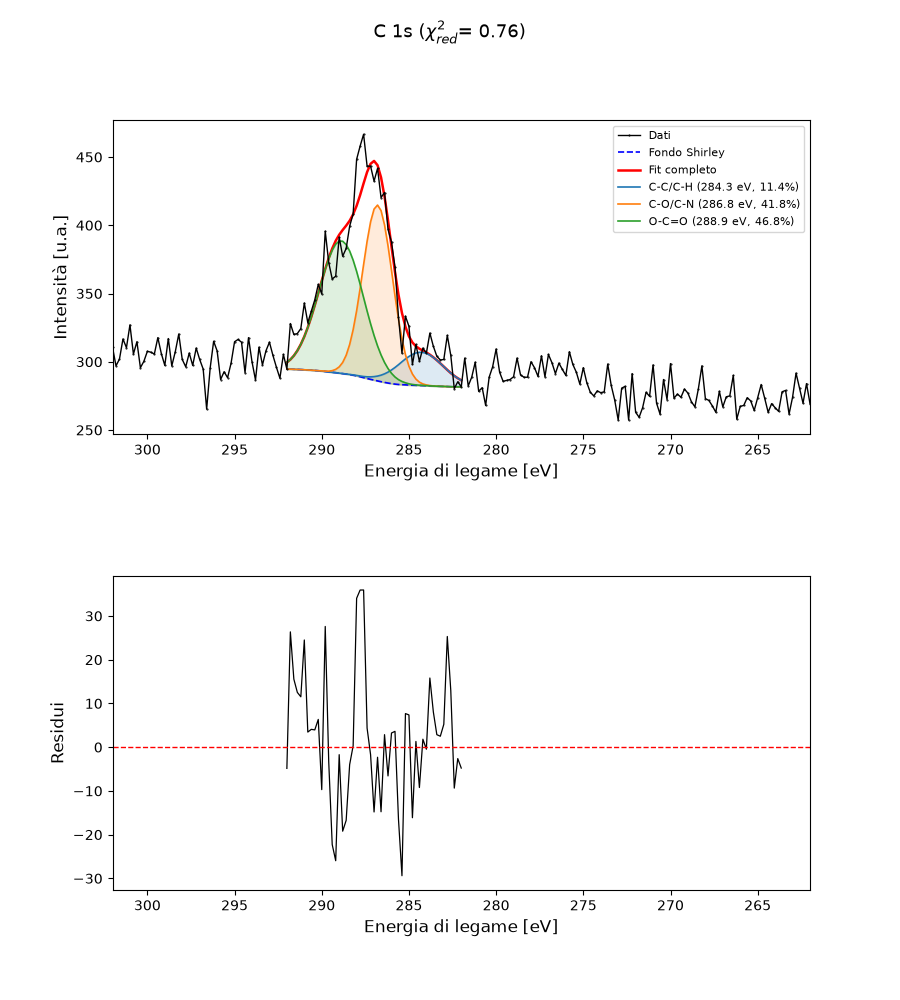

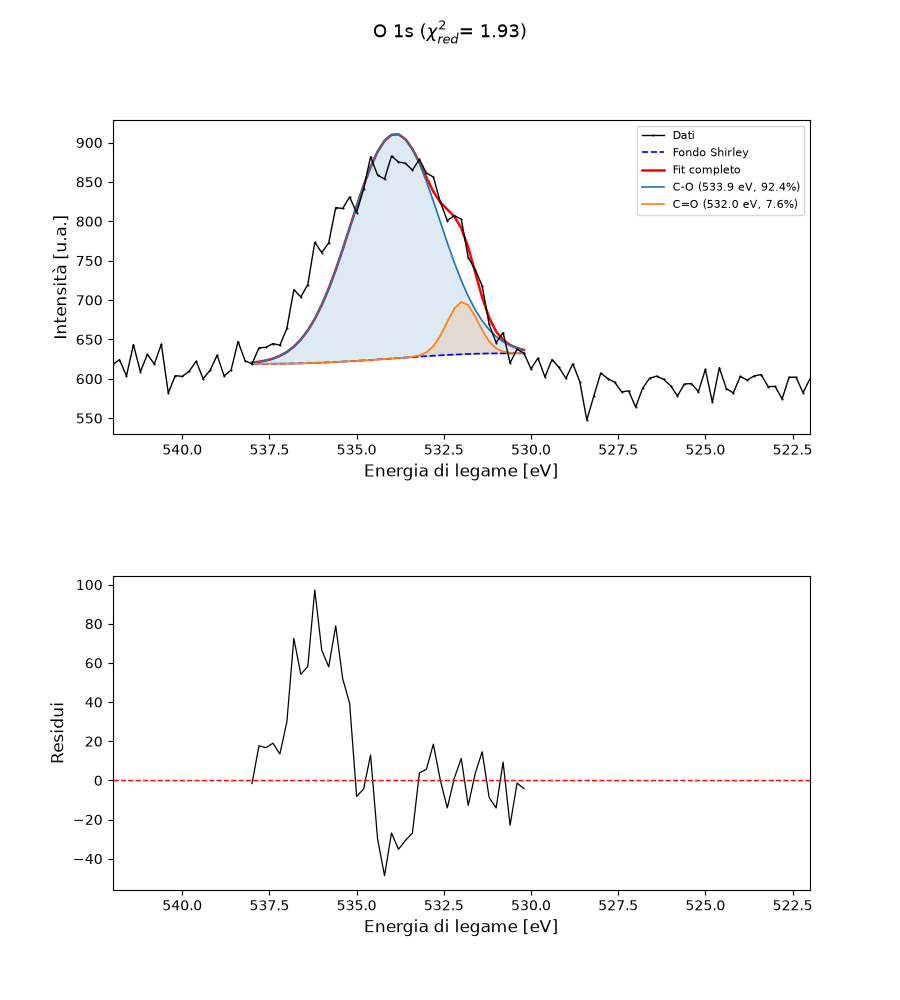


C 1s peaks:
  C-C/C-H     BE=284.30±1.41 eV  FWHM=3.00±2.60 eV  area=11.4%
  C-O/C-N     BE=286.80±0.21 eV  FWHM=2.01±0.56 eV  area=41.8%
  O-C=O       BE=288.88±0.66 eV  FWHM=3.00±0.88 eV  area=46.8%
  χ²_red = 0.7562

O 1s peaks:
  C-O         BE=533.90±0.16 eV  FWHM=3.00±0.33 eV  area=92.4%
  C=O         BE=531.97±0.21 eV  FWHM=1.06±0.68 eV  area=7.6%
  χ²_red = 1.9305


In [84]:
# Fit of the C 1s and O 1s regions for each spectrum

c1s_fit = fit_xps_region(spectra[1]['C 1s'], (282, 292), 'C 1s')
o1s_fit = fit_xps_region(spectra[1]['O 1s'], (530, 538), 'O 1s')

# print peak summary
for fit, name in [(c1s_fit, 'C 1s'), (o1s_fit, 'O 1s')]:
    print(f"\n{name} peaks:")
    for pk in fit['peak_params']:
        print(f"  {pk['label']:10s}  BE={pk['position_eV']:.2f}±{pk['position_err']:.2f} eV"
                f"  FWHM={pk['fwhm_eV']:.2f}±{pk['fwhm_err']:.2f} eV"
                f"  area={100*pk['area_fraction']:.1f}%")
    print(f"  χ²_red = {fit['chi2_red']:.4f}")

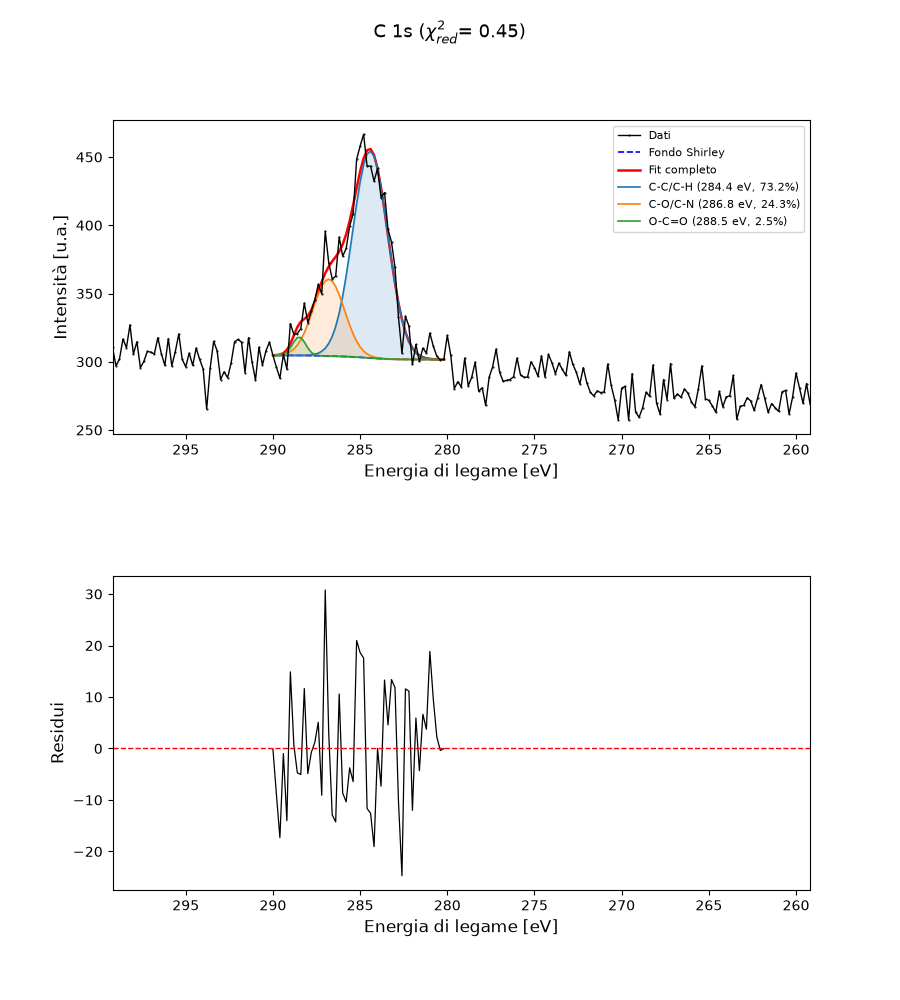

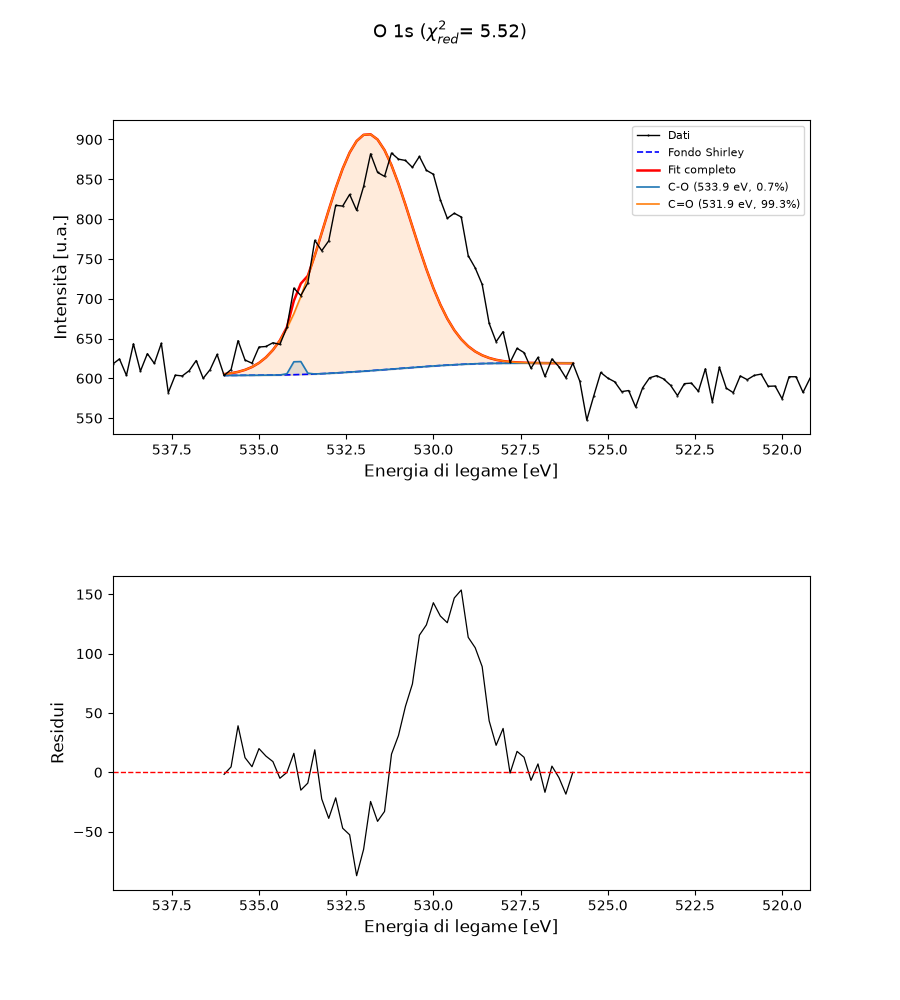


C 1s peaks:
  C-C/C-H     BE=284.42±0.18 eV  FWHM=2.37±0.27 eV  area=73.2%
  C-O/C-N     BE=286.80±0.33 eV  FWHM=2.12±1.07 eV  area=24.3%
  O-C=O       BE=288.50±0.36 eV  FWHM=0.88±0.97 eV  area=2.5%
  χ²_red = 0.4541

O 1s peaks:
  C-O         BE=533.90±0.43 eV  FWHM=0.30±2.19 eV  area=0.7%
  C=O         BE=531.90±0.13 eV  FWHM=3.00±0.32 eV  area=99.3%
  χ²_red = 5.5234


In [86]:
# Fit of the C 1s and O 1s regions for each spectrum

c1s_fit = fit_xps_region(spectra[1]['C 1s'], (280, 290), 'C 1s', BE_shift=BE_shift)
o1s_fit = fit_xps_region(spectra[1]['O 1s'], (526, 536), 'O 1s', BE_shift=BE_shift)

# print peak summary
for fit, name in [(c1s_fit, 'C 1s'), (o1s_fit, 'O 1s')]:
    print(f"\n{name} peaks:")
    for pk in fit['peak_params']:
        print(f"  {pk['label']:10s}  BE={pk['position_eV']:.2f}±{pk['position_err']:.2f} eV"
                f"  FWHM={pk['fwhm_eV']:.2f}±{pk['fwhm_err']:.2f} eV"
                f"  area={100*pk['area_fraction']:.1f}%")
    print(f"  χ²_red = {fit['chi2_red']:.4f}")

In [ ]:
# Fit of the C 1s and O 1s regions for each spectrum using an active background
for kk, legend in enumerate(legends_raw):
    print(f"\n{'='*40}\n{legend}\n{'='*40}")

    c1s_fit = fit_xps_region_active(spectra[kk]['C 1s'], (282, 292), 'C1s')
    o1s_fit = fit_xps_region_active(spectra[kk]['O 1s'], (528, 538), 'O1s')

    # print peak summary
    for fit, name in [(c1s_fit, 'C 1s'), (o1s_fit, 'O 1s')]:
        print(f"\n{name} peaks:")
        for pk in fit['peak_params']:
            print(f"  {pk['label']:10s}  BE={pk['position_eV']:.2f}±{pk['position_err']:.2f} eV"
                  f"  FWHM={pk['fwhm_eV']:.2f}±{pk['fwhm_err']:.2f} eV"
                  f"  area={100*pk['area_fraction']:.1f}%")
        print(f"  χ²_red = {fit['chi2_red']:.4f}")